## **OpenCV kullanarak resim ve şekil çizme**

İlk olarak OpenCV ve numpy kütüphanelerini içe aktaralım ve imshow fonksiyonumuzu tanımlayalım

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

#Boş bir kare tuval oluşturarak başlayalım.

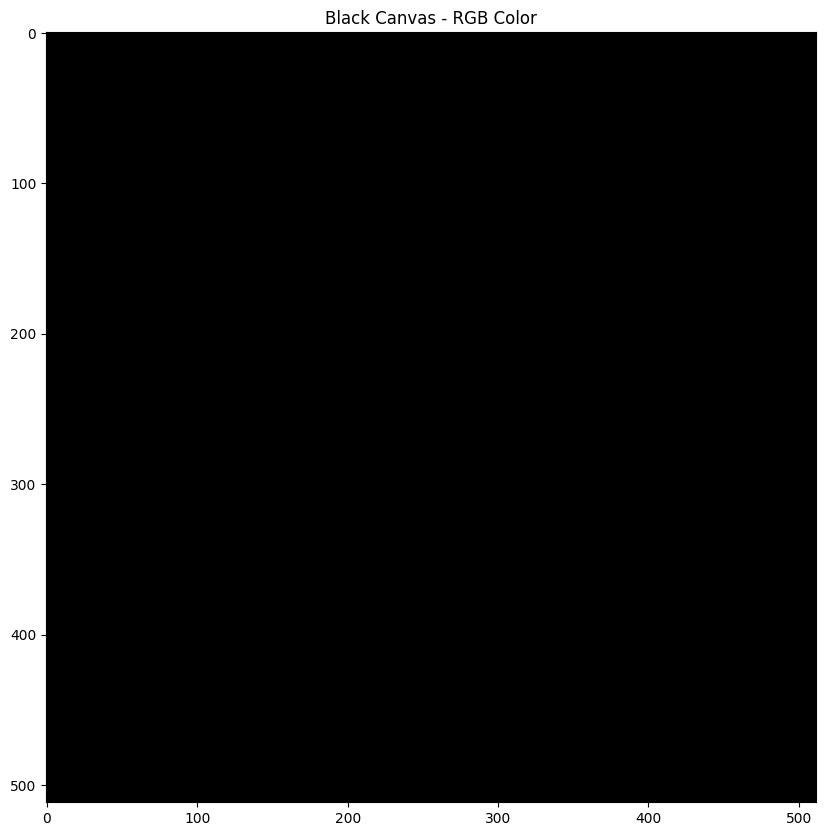

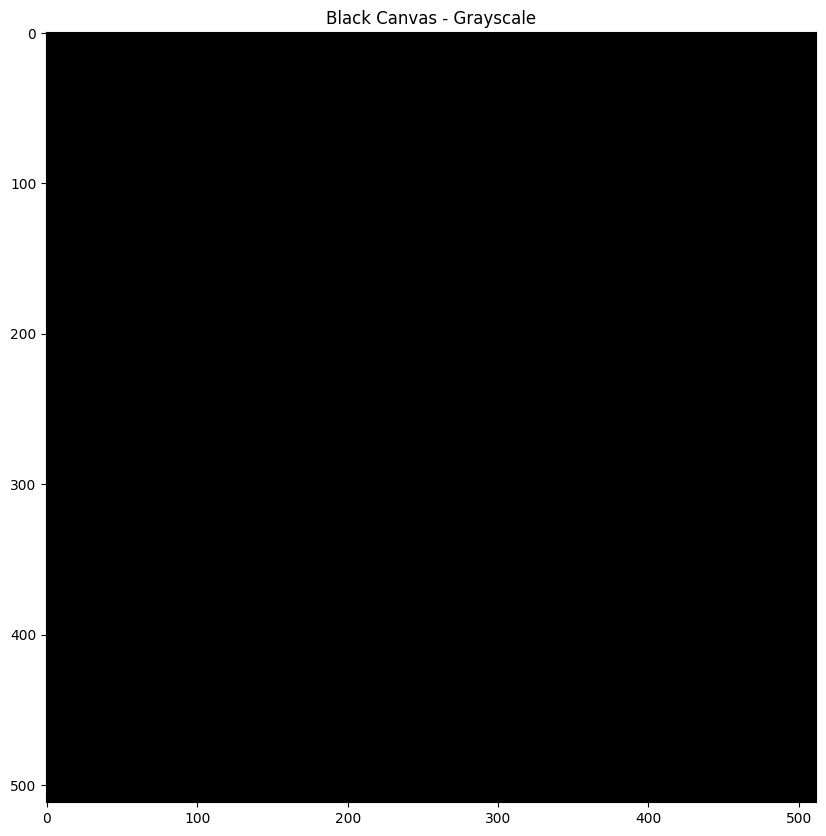

In [2]:
# Create a black image using numpy to create and array of black
# Numpy kullanarak siyah bir resim oluşturmak için tüm elemanları 0 olan bir tensor oluştur.
image = np.zeros((512,512,3), np.uint8)

# Aynı ölçüde grayscale oluşturalım
image_gray = np.zeros((512,512), np.uint8)

# Bir gri tonlamalı veya renkli görüntüde siyah aynı olurdu (beyaz için de aynı).
imshow("Black Canvas - RGB Color", image)
imshow("Black Canvas - Grayscale", image_gray)

### **Siyah karemizin üzerine bir çizgi çizmek için cv2.line kullanalım.**
cv2.line(image, starting cordinates, ending cordinates, color, thickness)
cv2.line(görüntü, başlangıç koordinatları, bitiş koordinatları, renk, kalınlık)

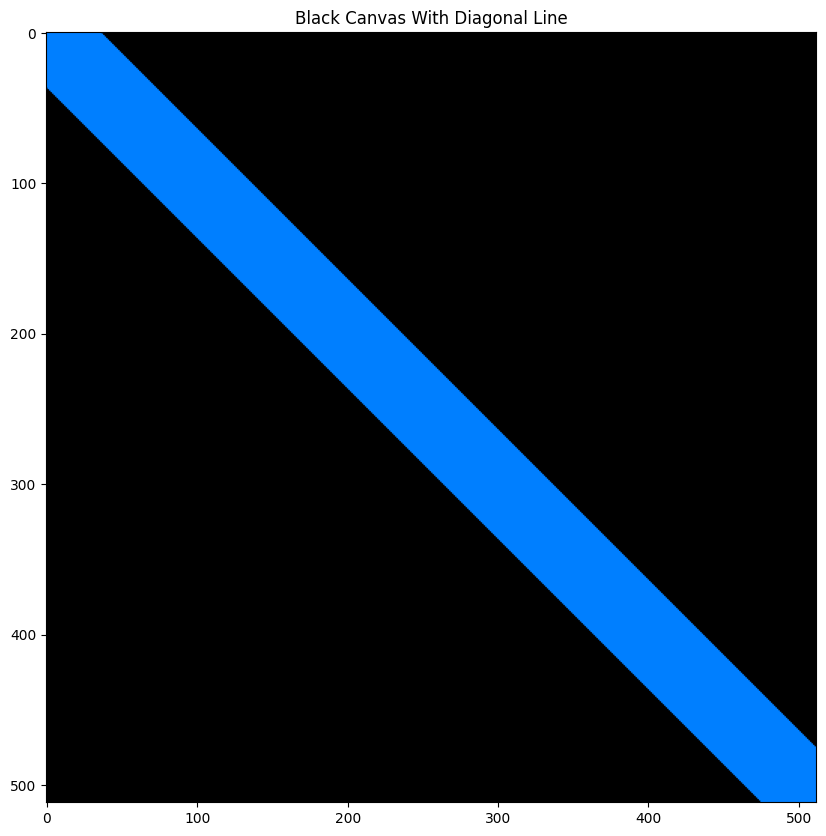

In [5]:
# Note this is an inplace operation, meaning it changes the input image
# Unlike many other OpenCV functions that return a new image leaving the input unaffected
# Remember our image was the black canvas
# Unutmayın, Girdiyi etkilenmeden bırakan diğer birçok OpenCV fonksiyonunun aksine bu resim 
# üzerinde yapılan bir işlemdir, yani girdi görüntüsünü değiştirir
# Görüntümüzün siyah tuval olduğunu unutmayın
cv2.line(image, (0,0), (520,520), (255,127,0), 50)

imshow("Black Canvas With Diagonal Line", image)

### **Dörtgen Çizme**
cv2.rectangle(görüntü, başlangıç köşesi, karşı köşe, renk, kalınlık)
cv2.rectangle(image, starting vertex, opposite vertex, color, thickness)

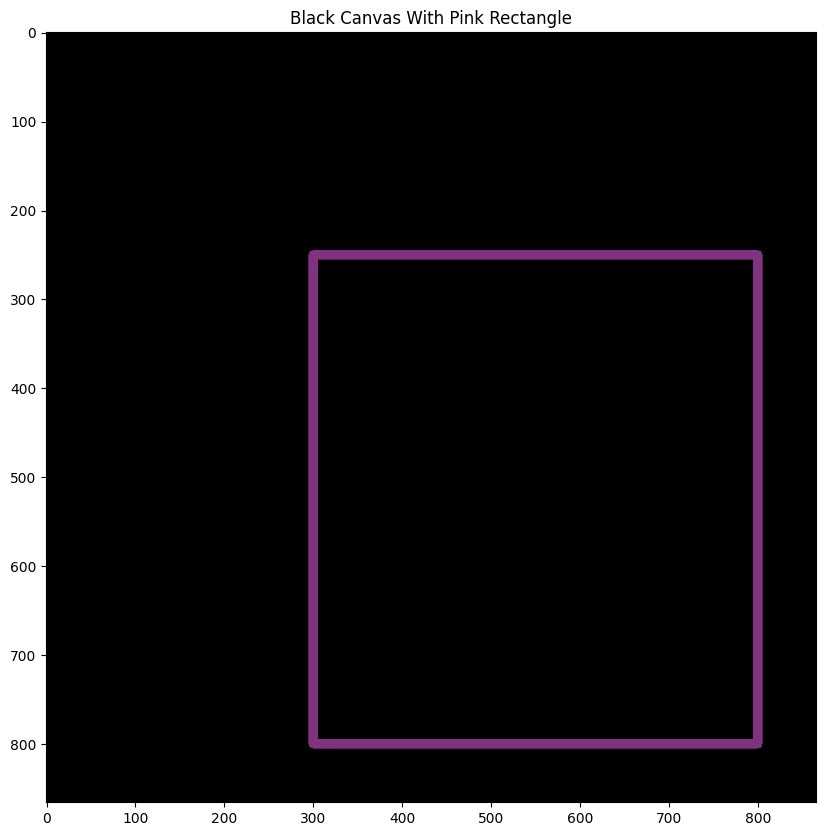

In [10]:

# Siyah tuvalimizi tekrar oluşturalım çünkü şimdi içinde bir çizgi var
image = np.zeros((866,866,4), np.uint8)

# Kalınlık - pozitifse. Kalınlık negatif ise, dolu olduğu anlamına gelir.
cv2.rectangle(image, (800,800), (300,250), (127,50,127), 10)
imshow("Black Canvas With Pink Rectangle", image)

### **Şimdi biraz daire çizelim mi?**

cv2.cirlce(image, center, radius, color, fill)
cv2.cirlce(image, merkez, yarıçap, renk, doldurma)

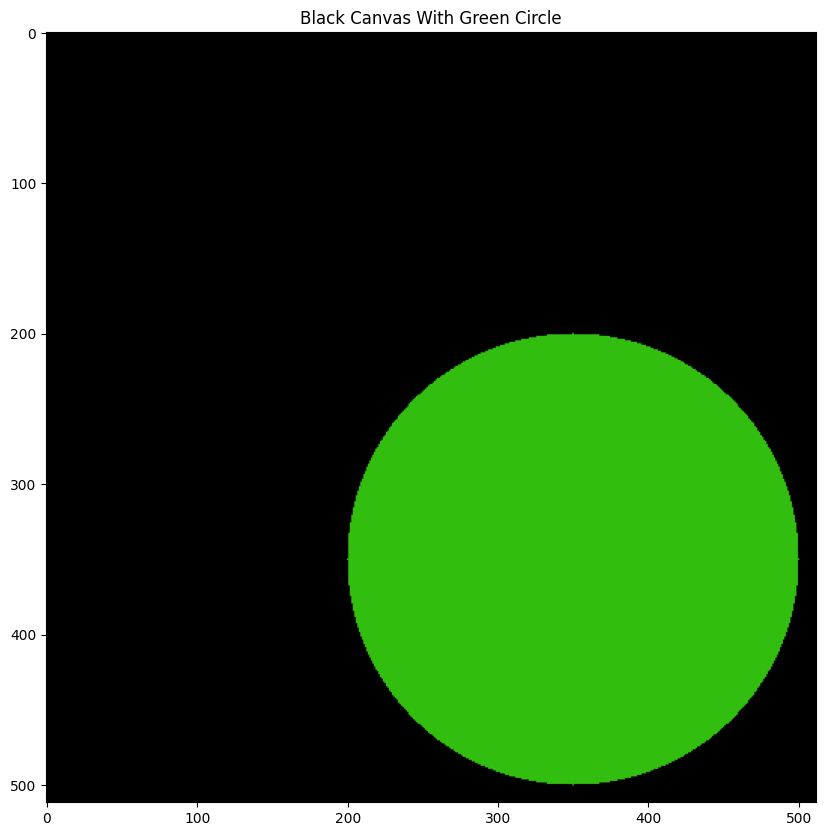

In [19]:
image = np.zeros((512,512,3), np.uint8)

cv2.circle(image, (350, 350), 150, (15,190,50),-5) 
imshow("Black Canvas With Green Circle", image)

Çokgenler

cv2.polylines(image, noktalar, Kapalı mı?, renk, kalınlık)

Eğer Closed = True ise, ilk ve son noktaları birleştiririz.

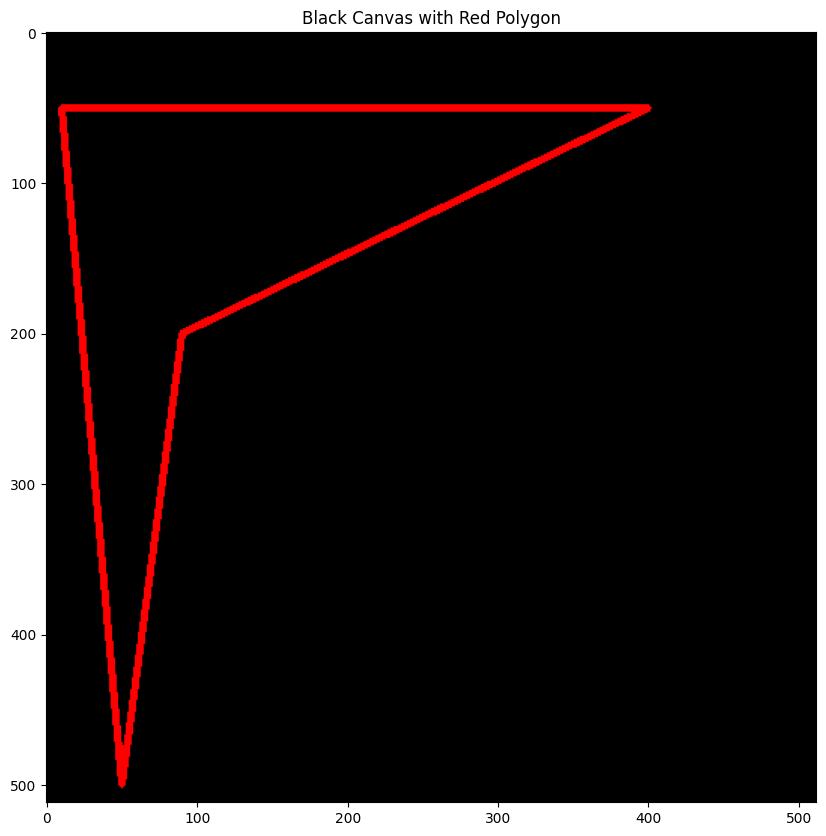

In [24]:
image = np.zeros((512,512,4), np.uint8)

# Dört nokta tanımlayalım
pts = np.array( [[10,50], [400,50], [90,200], [50,500]], np.int32)

# Şimdi noktalarımızı çoklu çizgiler tarafından istenen şekilde yeniden şekillendirelim.
pts = pts.reshape((-1,1,2))

cv2.polylines(image, [pts], True, (0,0,255), 3)
imshow("Black Canvas with Red Polygon", image)

**Not** cv2.polylines, verilerimizin bu şekilde şekillendirilmesini gerektirir:

In [25]:
pts = np.array( [[10,50], [400,50], [90,200], [50,500]], np.int32)
pts.shape

(4, 2)

In [26]:
pts = pts.reshape((-1,1,2))
pts.shape

(4, 1, 2)

### **cv2.putText ile metin eklemeye**

cv2.putText(image, 'Text to Display', bottom left starting point, Font, Font Size, Color, Thickness)
cv2.putText(image, 'Görüntülenecek Metin', sol alt başlangıç noktası, Yazı Tipi, Yazı Tipi Boyutu, Renk, Kalınlık)

**Mevcut Yazı Tipleri**
- FONT_HERSHEY_SIMPLEX, FONT_HERSHEY_PLAIN
- FONT_HERSHEY_DUPLEX,FONT_HERSHEY_COMPLEX 
- FONT_HERSHEY_TRIPLEX, FONT_HERSHEY_COMPLEX_SMALL
- FONT_HERSHEY_SCRIPT_SIMPLEX
- FONT_HERSHEY_SCRIPT_COMPLEX

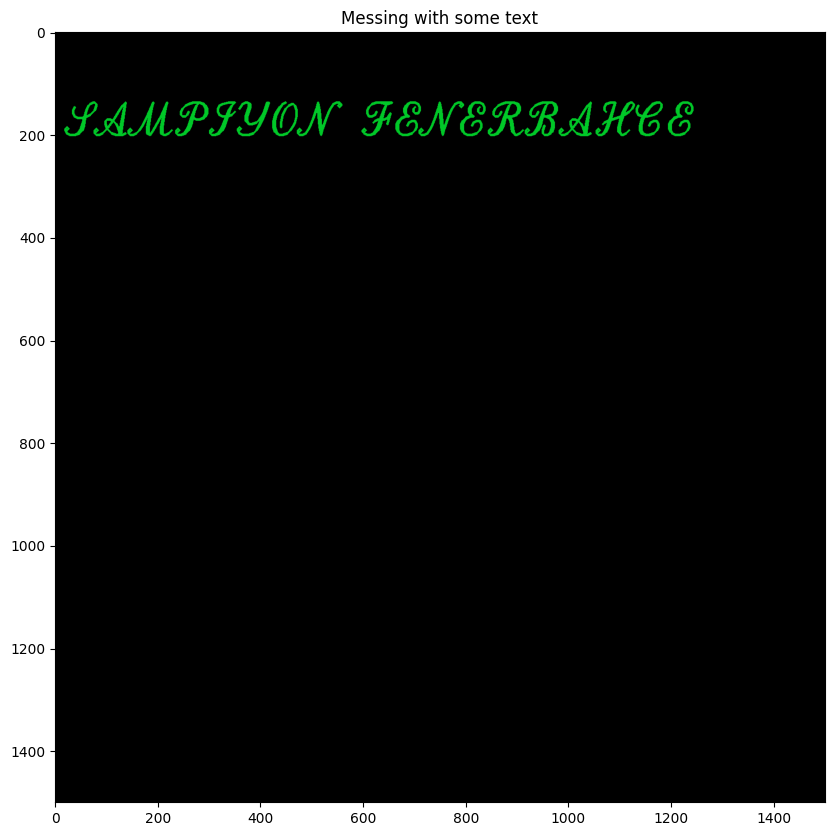

In [42]:
image = np.zeros((1500,1500,4), np.uint8)
ourString =  'SAMPIYON FENERBAHCE'
cv2.putText(image, ourString, (20,200), cv2.FONT_HERSHEY_SCRIPT_COMPLEX, 3, (40,200,0,255), 4)
imshow("Messing with some text", image)